In [1]:
import warnings
warnings.filterwarnings('ignore')

In [30]:
from typing import Any, Optional
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.datasets import fashion_mnist

## Helper Functions

In [31]:
def about_vector(
   vector: Any,
   shape: Optional[bool] = False,
   size: Optional[bool] = False,
   dtype: Optional[bool] = False,
   value: Optional[bool] = False,
   n_dim: Optional[bool] = False
) -> None:
   """Display selected details about a TensorFlow vector."""
   print(f"Vector: \n {vector}")
   print("-"*30)
   if shape:
     print(f"Shape of Vector: {vector.shape}") 
     print("-"*30)
   if size:
     print(f"Size of Vector: {tf.size(vector)}") 
     print("-"*30)
   if dtype:
     print(f"Datatype of Vector: {vector.dtype}") 
     print("-"*30)
   if value:
     print(f"Value of Vector: {vector.numpy()}") 
     print("-"*30)
   if n_dim:
     print(f"Dimention of Vector: {vector.ndim}")

def model_summary(model: Any, history: Any) -> tuple[Any, Any]:
    """Plot training curves and return the model summary and figure."""
    summary = model.summary()
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Accuracy
    axes[0].plot(acc, label="Training Accuracy")
    axes[0].plot(val_acc, label="Validation Accuracy")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    # Loss
    axes[1].plot(loss, label="Training Loss")
    axes[1].plot(val_loss, label="Validation Loss")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    fig.suptitle(f"Learning Curve of {model.name}")

    return summary, fig

def best_learning_rate(history: Any, epochs:int, model_name: str) -> None:
    """Plot loss across learning rates and highlight the best rate."""
    lrs = 1e-4 * (10**(tf.range(epochs)/20)) 
    losses = history.history['loss'] 

    # Finding the lowest loss and position of the learning rate 
    min_idx = np.argmin(losses) 
    min_lr = lrs[min_idx] 
    min_loss = losses[min_idx] 

    plt.figure(figsize=(8,5)) 
    plt.semilogx(lrs,history.history['loss'], label="Loss") 
    plt.scatter(
        min_lr, 
        min_loss, 
        label=f"Best LR: {np.round(min_lr, 2)}", color="red",
    )

    # Annotation
    min_lr_label = np.round(min_lr, 2)
    min_loss_label = np.round(min_loss, 2)
    plt.annotate(
        f"(Lr: {min_lr_label}, Loss: {min_loss_label})",
        xy=(min_lr_label, min_loss_label),
        xytext= (min_lr_label + 1e-1, min_loss_label)
    )
    plt.xlabel("Learning rate") 
    plt.ylabel("Loss") 
    plt.title(f"learning rate v/s Loss for {model_name}")
    plt.legend()
    plt.show()

In [3]:
# Loading the data
(train_data, train_labels),(test_data, test_labels) =  fashion_mnist.load_data()

In [4]:
# Shape of the Data
print(f"Shape of train_data: {train_data.shape}")
print(f"Shape of test_data: {test_data.shape}")

Shape of train_data: (60000, 28, 28)
Shape of test_data: (10000, 28, 28)


In [5]:
# Shape of a Sample
print(f"Shape of TrainData Sample: {train_data[0].shape}")
print(f"Shape of TrainData Lable: {train_labels[0].shape}")

Shape of TrainData Sample: (28, 28)
Shape of TrainData Lable: ()


In [6]:
# Sample of Data
print(f"Training Sample:\n{train_data[0]}\n")
print(f"Training label:\n{train_labels[0]}\n")

Training Sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [7]:
# Adding Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

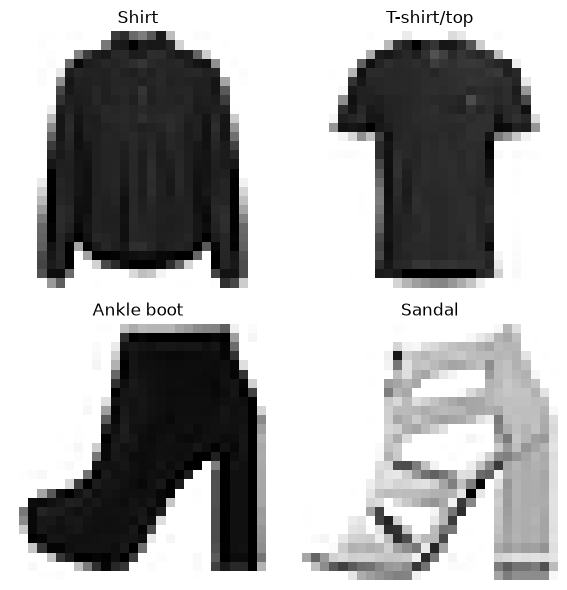

In [8]:
# Random Sample Image of the Training Data
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
ax = ax.ravel()
for i in range(4):
    random_index = np.random.randint(0, len(train_data))
    ax[i].imshow(train_data[random_index], cmap="binary")
    ax[i].set_title(class_names[train_labels[random_index]])
    ax[i].axis("off")

plt.tight_layout()
plt.show()


In [9]:
# Findings
print(f"Input Shape of the model will be: {28 * 28}")
print(f"Output Shape of the model will be: {10}")

Input Shape of the model will be: 784
Output Shape of the model will be: 10


## Activation Function Softmax

$\boxed{ P(y=i)= \frac{e^{z_i}} {\sum_{j=1}^{n}e^{z_j}} }$


In [10]:
import numpy as np

def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    softmax = exp_z / np.sum(exp_z)
    return softmax

logits = np.array([1, 2, 3])
print(softmax(logits))

[0.09003057 0.24472847 0.66524096]


# Building Multiclass Classification Models


In [11]:
# splitting data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_data,
    train_labels,
    test_size=0.3,
    random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (42000, 28, 28)
Shape of y_train: (42000,)
Shape of X_test: (18000, 28, 28)
Shape of y_test: (18000,)


## Model 1


In [12]:
# Model 1

# 1. set the random seed
tf.random.set_seed(42)

# 2. Creating the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
], name="Model_1")

# 3. Compile the model_1
model_1.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# 4. Fitting the model_1
history_1 = model_1.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10
)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0985 - loss: 2.4847 - val_accuracy: 0.0988 - val_loss: 2.3043
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0976 - loss: 2.3028 - val_accuracy: 0.0988 - val_loss: 2.3043
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.0988 - val_loss: 2.3043
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0975 - loss: 2.3028 - val_accuracy: 0.0988 - val_loss: 2.3043
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0975 - loss: 2.3028 - val_accuracy: 0.0988 - val_loss: 2.3043
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0975 - loss: 2.3028 - val_accuracy: 0.0988 - val_loss: 2.3043
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.0974 - loss: 2.3028 - val_accuracy: 0.0988 - val_loss: 2.3043
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0974 - loss: 2.3028 

Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,897 (93.35 KB)

 Trainable params: 7,965 (31.11 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,932 (62.24 KB)

None


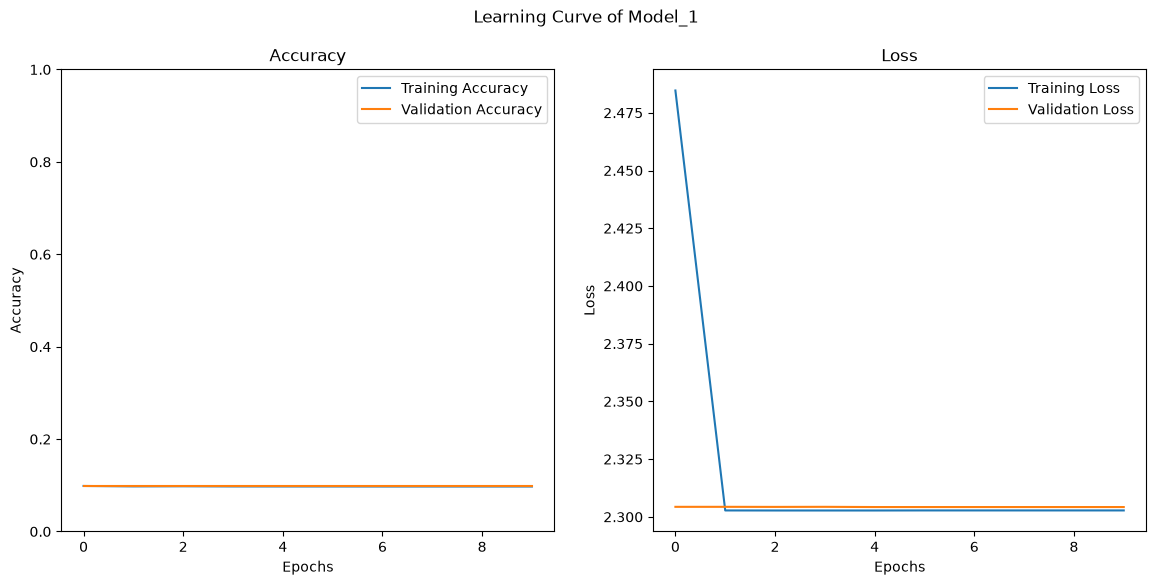

In [32]:
summary, figure = model_summary(
    model= model_1,
    history= history_1
)

print(summary)
figure.show()

- The learning curve clearly demonstrates **severe underfitting**.
- Both training and validation accuracy remain extremely low, struggling to reach 40% (0.4) by the end of 10 epochs.

- The loss values start exceptionally high and decrease slowly, ending roughly around 1.3, which indicates the model is failing to grasp the underlying patterns of the dataset.

- This poor performance is expected because the architecture is too shallow and narrow (hidden layers with only 10 and 5 neurons). With just 7,965 trainable parameters, the model lacks the capacity to represent the complexity of the clothing images.Model 2


## Model 2


In [14]:
# Minimum and Maximum value in a image pixels
X_train.min(), X_train.max()

(np.uint8(0), np.uint8(255))

In [15]:
# Normalizing the train data
X_train_data_norm = X_train/255
X_test_data_norm = X_test/255

# Our training and testing data is now in between 0 and 1 by dividing it by maximum.

In [16]:
X_train_data_norm.min(), X_train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [17]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(25, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
], name="Model_2")

model_2.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10
)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7330 - loss: 1.5651 - val_accuracy: 0.7787 - val_loss: 0.6789
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8079 - loss: 0.5637 - val_accuracy: 0.7919 - val_loss: 0.6461
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8254 - loss: 0.4976 - val_accuracy: 0.7961 - val_loss: 0.6294
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8314 - loss: 0.4726 - val_accuracy: 0.7966 - val_loss: 0.6269
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8418 - loss: 0.4454 - val_accuracy: 0.8053 - val_loss: 0.5884
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8487 - loss: 0.4279 - val_accuracy: 0.8288 - val_loss: 0.5031
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8584 - loss: 0.3979 - val_accuracy: 0.8424 - val_loss: 0.4566
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8618 - loss: 0.3877 

Model: "Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,257 (997.10 KB)

 Trainable params: 85,085 (332.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 170,172 (664.74 KB)

None


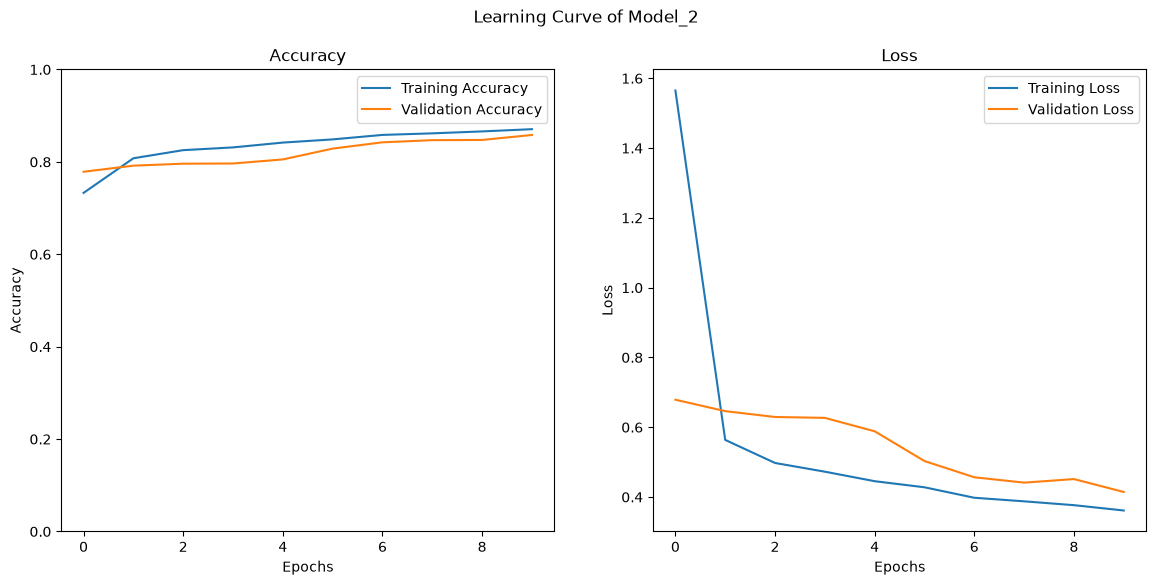

In [18]:
summary, figure = helper.model_summary(
    model= model_2,
    history= history_2
)

print(summary)
figure.show()

## Finding Best Learning Rate


In [ ]:
tf.random.set_seed(42)

model_3_lr_scheduler = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(25, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
], name="Model_3_LrSchedular")

model_3_lr_scheduler.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

lr_schedular = tf.keras.callbacks.LearningRateScheduler(
    lambda epochs: 1e-3 * 10**(epochs/20)
)

history_3 = model_3_lr_scheduler.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[lr_schedular]
)

Epoch 1/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4672 - loss: 1.8305 - val_accuracy: 0.5161 - val_loss: 1.2481 - learning_rate: 0.0010
Epoch 2/50


ValueError: x and y must have same first dimension, but have shapes (100,) and (10,)

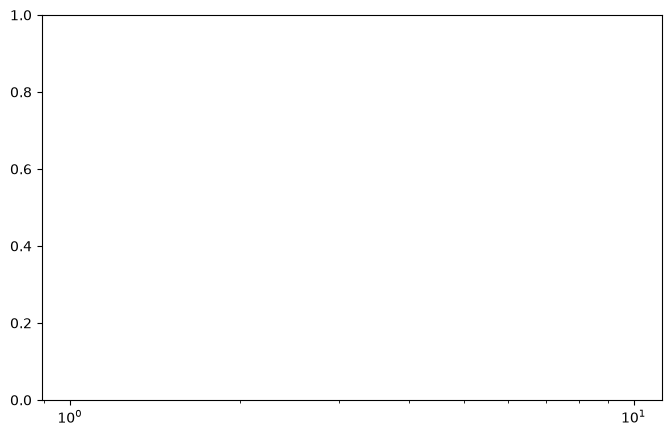

In [ ]:
best_learning_rate(
    history=history_3,
    epochs=50,
    model_name=model_3_lr_scheduler.name
)